# Cliff World Experiments
Comparing **Value Iteration**, **Q-Learning**, **SARSA**, and **Dyna-Q** on a GridWorld with cliff cells.

**Environment:** 4×12 grid (classic Sutton & Barto layout).
Start at bottom-left (3,0), goal at bottom-right (3,11).
Cliffs occupy the entire bottom row between start and goal — (3,1) to (3,10).

Two routes exist:
- **Risky (optimal):** go up one step to row 2, traverse right just above the cliffs, drop to goal — **13 steps**. One slip drops the agent onto a cliff.
- **Safe:** go up to row 1 (or row 0), traverse right, come back down — **17+ steps**. No cliff exposure.

**Key insight:** with *constant* epsilon both algorithms keep exploring throughout training.
Q-learning's off-policy max-bootstrap ignores exploration noise → learns the risky cliff-edge route.
SARSA's on-policy update feels the occasional slip into cliffs → learns the safer inland route.

In [26]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import (
    greedy_policy_from_V, evaluate,
    plot_env, plot_policy, plot_value_heatmap,
)
from helpers.rl import value_iteration, q_learning, sarsa
from helpers.dynaq import dyna_q

## Environment setup

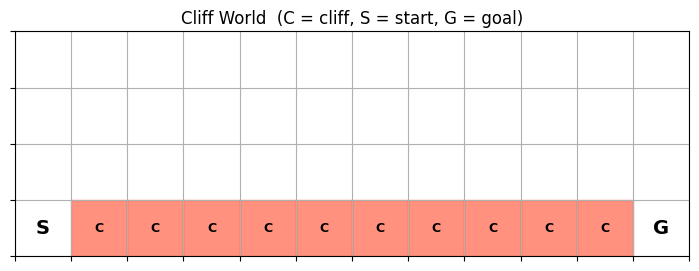

States: 48, Cliffs: 10, Slip prob: 0.0


In [27]:
# --- shared config ---
NUM_ROWS, NUM_COLS = 4, 12
START, GOAL = (3, 0), (3, 11)                        # bottom-left / bottom-right
CLIFF_CELLS = {(3, c) for c in range(1, 11)}         # bottom row between start and goal

# SLIP_PROB must be 0 for the classic Q-learning vs SARSA result.
# The cliff risk comes entirely from epsilon-greedy exploration randomly choosing DOWN.
# With environmental slip both algorithms experience identical actual cliff hits, which
# washes out the policy difference — Q-learning no longer prefers the risky path.
SLIP_PROB    = 0.0
STEP_REWARD  = -1.0
GOAL_REWARD  = 20.0
CLIFF_REWARD = -100.0
MAX_STEPS    = 200
GAMMA        = 0.99
SEED         = 42

def make_env():
    return SlipperyGridWorld(
        rows=NUM_ROWS, cols=NUM_COLS,
        start=START, goal=GOAL,
        slip_prob=SLIP_PROB,
        step_reward=STEP_REWARD,
        goal_reward=GOAL_REWARD,
        cliff_fields=CLIFF_CELLS,
        cliff_reward=CLIFF_REWARD,
        max_steps=MAX_STEPS,
        seed=SEED,
    )

env = make_env()
plot_env(env, title="Cliff World  (C = cliff, S = start, G = goal)")
print(f"States: {env.num_states}, Cliffs: {len(env.cliff_fields)}, Slip prob: {env.slip_prob}")

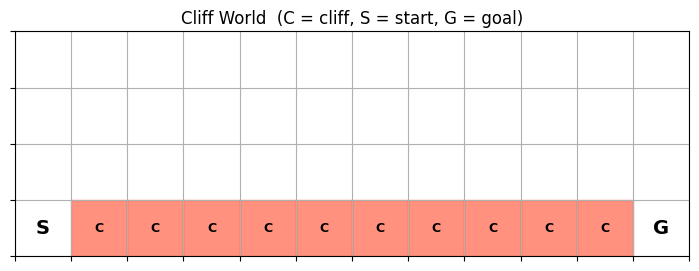

States: 48, Cliffs: 10, Slip prob: 0.0


In [28]:
plot_env(env, title="Cliff World  (C = cliff, S = start, G = goal)")
print(f"States: {env.num_states}, Cliffs: {len(env.cliff_fields)}, Slip prob: {env.slip_prob}")

## Value Iteration (model-based, exact)

In [29]:
env_vi = make_env()
V_vi, vi_iters = value_iteration(env_vi, max_iterations=500, gamma=GAMMA, threshold=1e-6)
pi_vi = greedy_policy_from_V(V_vi, env_vi, GAMMA)
metrics_vi = evaluate(env_vi, policy=pi_vi, n_episodes=500, seed=SEED)
print(f"Converged in {vi_iters} iterations")
print("Metrics:", metrics_vi)

Converged in 15 iterations
Metrics: {'avg_return': 8.0, 'std_return': 0.0, 'success_rate': 1.0, 'avg_steps': 13.0}


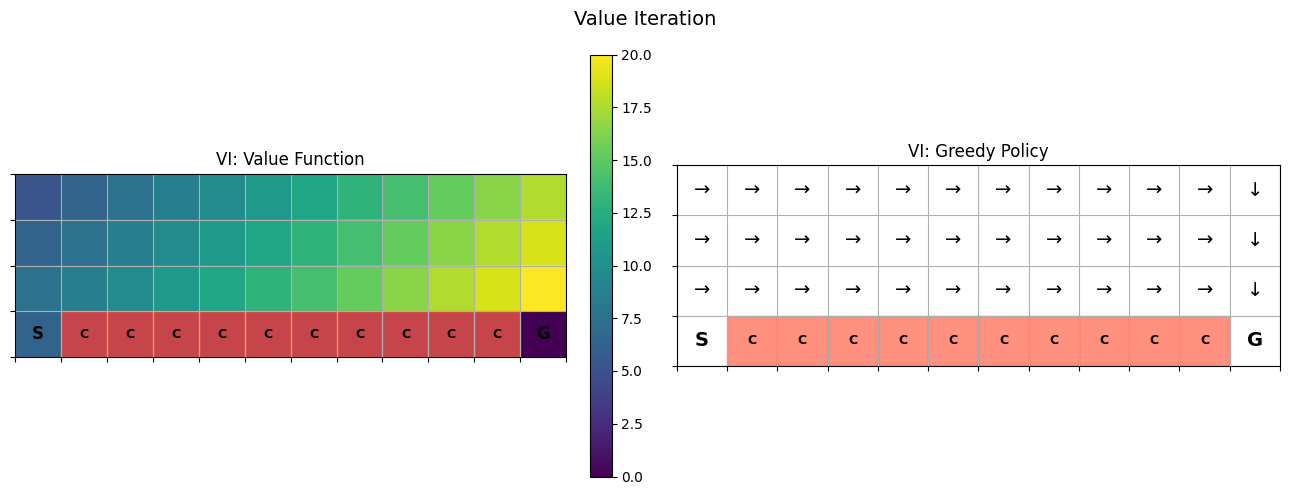

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_value_heatmap(env_vi, V_vi, title="VI: Value Function", ax=axes[0])
plot_policy(env_vi, pi_vi, title="VI: Greedy Policy", ax=axes[1])
plt.suptitle("Value Iteration", fontsize=14)
plt.tight_layout()
plt.savefig("cliff_vi.png", dpi=150)
plt.show()

## Q-Learning

In [31]:
N_EPISODES    = 10_000
ALPHA         = 0.1
# Constant epsilon — this is the key to reproducing the classic result.
# With decaying epsilon both algorithms converge to greedy and the difference disappears.
EPSILON       = 0.1
EPSILON_MIN   = 0.1   # same as EPSILON → no decay
EPSILON_DECAY = 1.0

env_ql = make_env()
Q_ql, rewards_ql = q_learning(
    env_ql, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
    seed=SEED,
)
metrics_ql = evaluate(env_ql, Q=Q_ql, n_episodes=500, seed=SEED)
print("Q-Learning metrics:", metrics_ql)

Q-Learning metrics: {'avg_return': 8.0, 'std_return': 0.0, 'success_rate': 1.0, 'avg_steps': 13.0}


## SARSA

In [32]:
env_sarsa = make_env()
Q_sarsa, rewards_sarsa = sarsa(
    env_sarsa, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
    seed=SEED,
)
metrics_sarsa = evaluate(env_sarsa, Q=Q_sarsa, n_episodes=500, seed=SEED)
print("SARSA metrics:", metrics_sarsa)

SARSA metrics: {'avg_return': 6.0, 'std_return': 0.0, 'success_rate': 1.0, 'avg_steps': 15.0}


## Dyna-Q

In [33]:
N_PLANNING = 5

env_dynaq = make_env()
Q_dynaq, rewards_dynaq = dyna_q(
    env_dynaq, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
    n_planning_steps=N_PLANNING,
    seed=SEED,
)
metrics_dynaq = evaluate(env_dynaq, Q=Q_dynaq, n_episodes=500, seed=SEED)
print(f"Dyna-Q (n={N_PLANNING}) metrics:", metrics_dynaq)

Dyna-Q (n=5) metrics: {'avg_return': 8.0, 'std_return': 0.0, 'success_rate': 1.0, 'avg_steps': 13.0}


## Comparison: Convergence curves

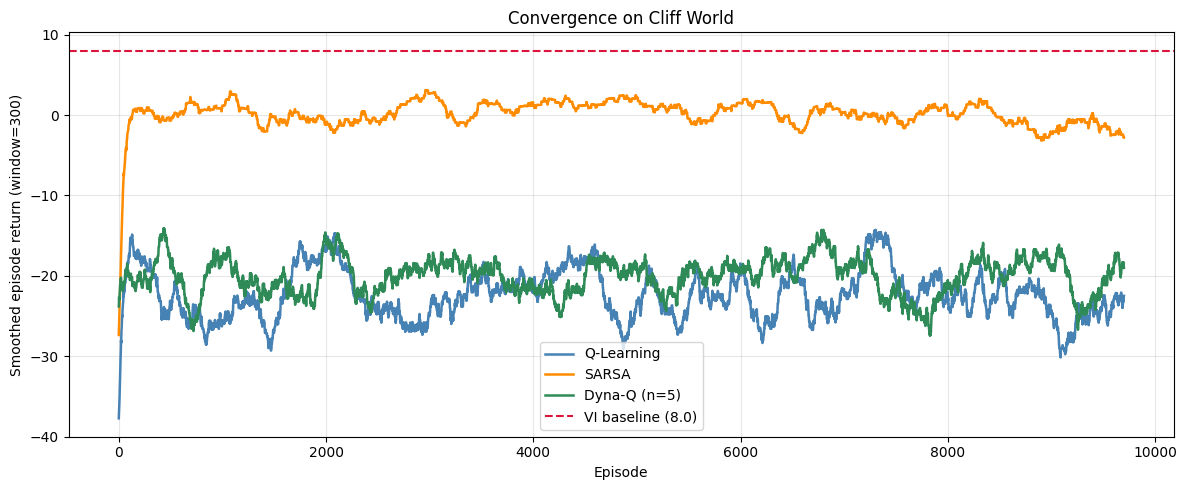

In [34]:
def smooth(x, w=300):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(figsize=(12, 5))

for rewards, label, color in [
    (rewards_ql,    "Q-Learning",        "steelblue"),
    (rewards_sarsa, "SARSA",             "darkorange"),
    (rewards_dynaq, f"Dyna-Q (n={N_PLANNING})", "seagreen"),
]:
    s = smooth(rewards)
    ax.plot(s, label=label, color=color, linewidth=1.8)

# VI is episode-independent — show as horizontal reference
vi_ref = metrics_vi["avg_return"]
ax.axhline(vi_ref, color="crimson", linestyle="--", linewidth=1.5, label=f"VI baseline ({vi_ref:.1f})")

ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed episode return (window=300)")
ax.set_title("Convergence on Cliff World")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cliff_convergence.png", dpi=150)
plt.show()

## Comparison: Evaluation metrics

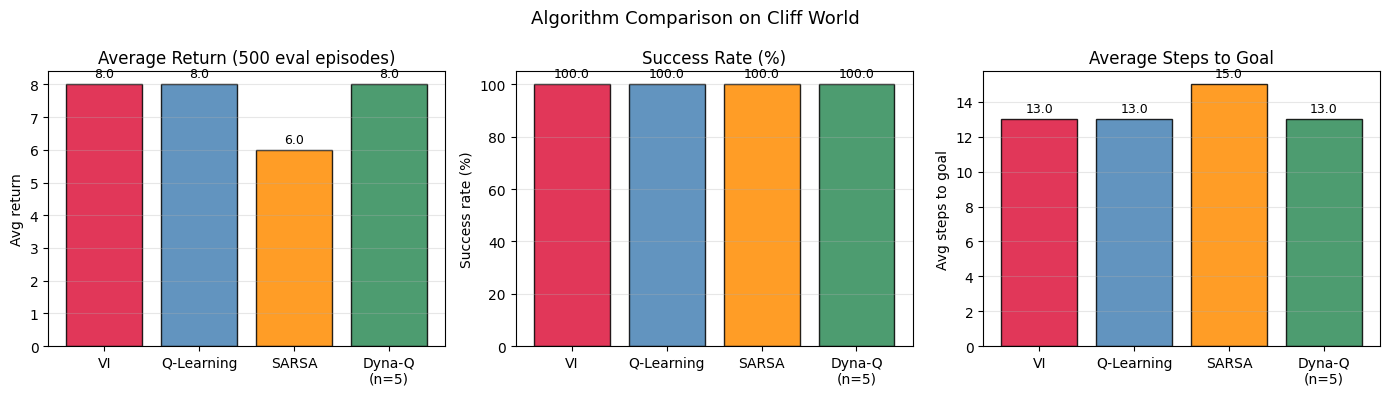

In [35]:
algo_names   = ["VI", "Q-Learning", "SARSA", f"Dyna-Q\n(n={N_PLANNING})"]
all_metrics  = [metrics_vi, metrics_ql, metrics_sarsa, metrics_dynaq]
colors       = ["crimson", "steelblue", "darkorange", "seagreen"]

avg_returns  = [m["avg_return"]  for m in all_metrics]
success_rates= [m["success_rate"] * 100 for m in all_metrics]
avg_steps    = [m["avg_steps"]   for m in all_metrics]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, values, ylabel, title in zip(
    axes,
    [avg_returns, success_rates, avg_steps],
    ["Avg return", "Success rate (%)", "Avg steps to goal"],
    ["Average Return (500 eval episodes)",
     "Success Rate (%)",
     "Average Steps to Goal"],
):
    bars = ax.bar(algo_names, values, color=colors, alpha=0.85, edgecolor="black")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Algorithm Comparison on Cliff World", fontsize=13)
plt.tight_layout()
plt.savefig("cliff_metrics.png", dpi=150)
plt.show()

## Policy comparison

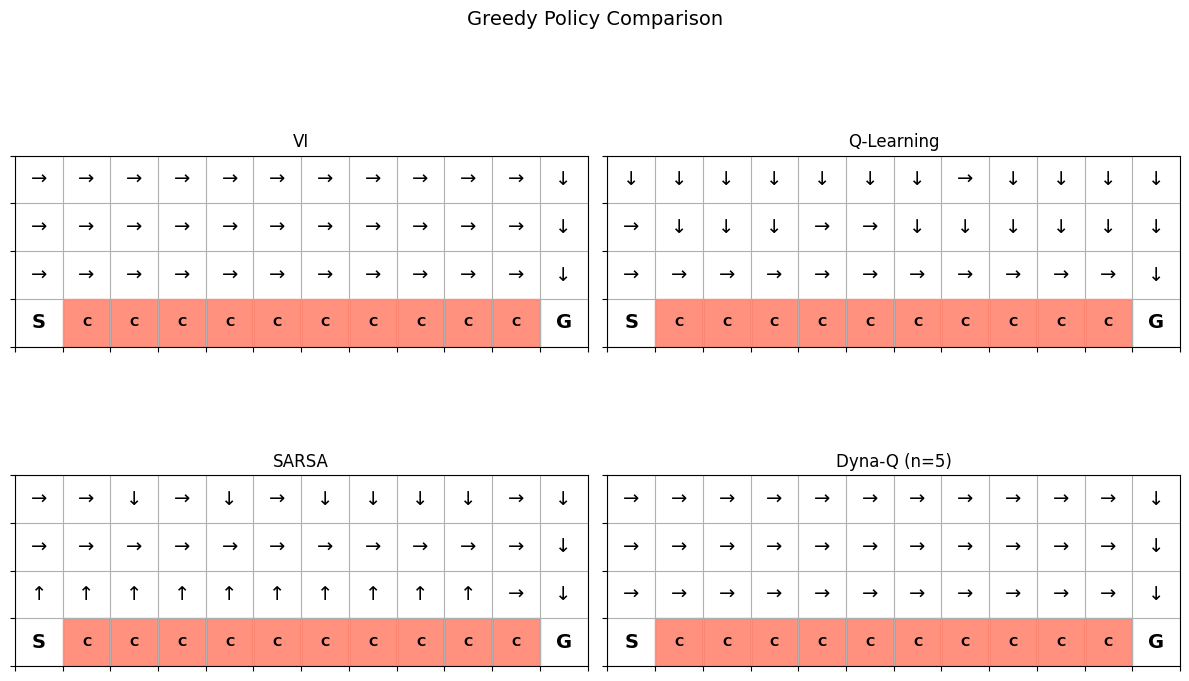

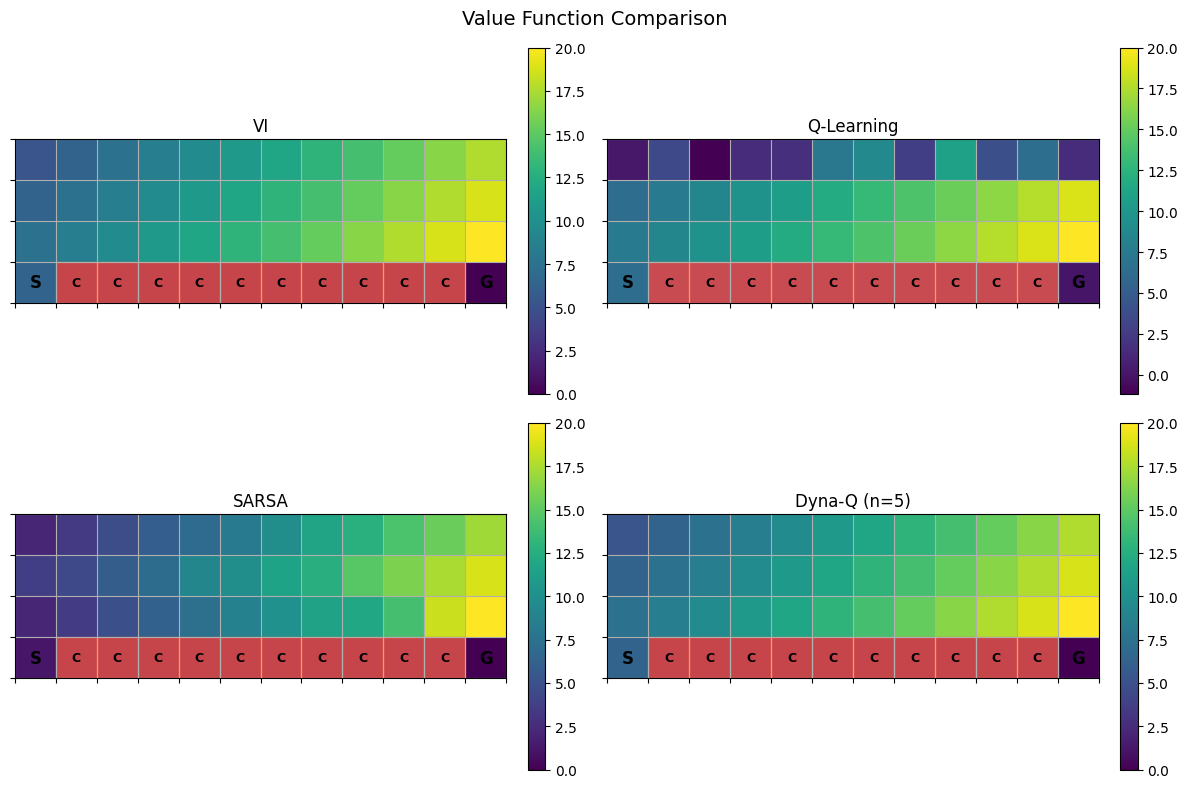

In [36]:
pi_ql    = np.argmax(Q_ql,    axis=1).astype(float)
pi_sarsa = np.argmax(Q_sarsa, axis=1).astype(float)
pi_dynaq = np.argmax(Q_dynaq, axis=1).astype(float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, policy, env_ref, title in zip(
    axes.flat,
    [pi_vi,    pi_ql,        pi_sarsa, pi_dynaq],
    [env_vi,   env_ql,       env_sarsa, env_dynaq],
    ["VI", "Q-Learning", "SARSA", f"Dyna-Q (n={N_PLANNING})"],
):
    plot_policy(env_ref, policy, title=title, ax=ax)

plt.suptitle("Greedy Policy Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("cliff_policies.png", dpi=150)
plt.show()

# --- value heatmap comparison ---
V_ql    = np.max(Q_ql,    axis=1)
V_sarsa = np.max(Q_sarsa, axis=1)
V_dynaq = np.max(Q_dynaq, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, V, env_ref, title in zip(
    axes.flat,
    [V_vi,     V_ql,         V_sarsa,  V_dynaq],
    [env_vi,   env_ql,       env_sarsa, env_dynaq],
    ["VI", "Q-Learning", "SARSA", f"Dyna-Q (n={N_PLANNING})"],
):
    plot_value_heatmap(env_ref, V, title=title, ax=ax)

plt.suptitle("Value Function Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("cliff_values.png", dpi=150)
plt.show()

## Dyna-Q ablation: effect of planning steps
How many real episodes does Dyna-Q need to match Q-Learning, as a function of `n_planning_steps`?

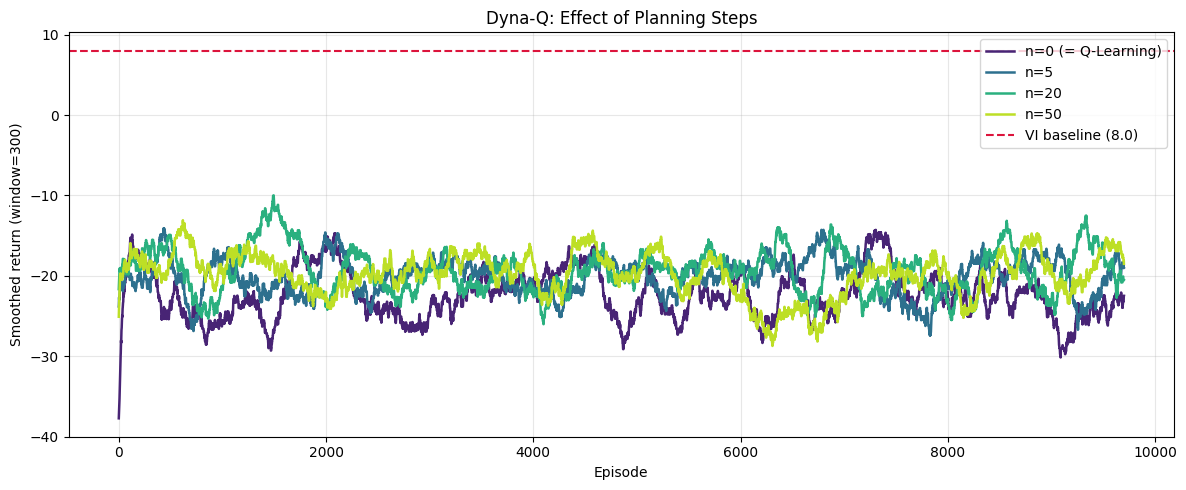

In [37]:
planning_values = [0, 5, 20, 50]
ablation_rewards = {}

for n in planning_values:
    e = make_env()
    _, rews = dyna_q(
        e, n_episodes=N_EPISODES,
        alpha=ALPHA, gamma=GAMMA,
        epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
        n_planning_steps=n,
        seed=SEED,
    )
    ablation_rewards[n] = rews

fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(planning_values)))

for (n, rews), color in zip(ablation_rewards.items(), cmap):
    label = f"n={n}" + (" (= Q-Learning)" if n == 0 else "")
    ax.plot(smooth(rews), label=label, color=color, linewidth=1.8)

ax.axhline(metrics_vi["avg_return"], color="crimson", linestyle="--",
           linewidth=1.5, label=f"VI baseline ({metrics_vi['avg_return']:.1f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed return (window=300)")
ax.set_title("Dyna-Q: Effect of Planning Steps")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cliff_dynaq_ablation.png", dpi=150)
plt.show()

## Conclusions

### Value Iteration
- Computes the **exact optimal policy** using the full transition model.
- With `slip_prob=0`, VI finds the 13-step risky path as optimal — there is no environmental
  noise to fear, and the greedy policy never randomly picks DOWN.

### Q-Learning vs SARSA on cliff environments
The mechanism requires **zero environmental slip** and **constant epsilon**:

- **Q-Learning** (off-policy): update target is $\max_{a'} Q(s', a')$.  
  This assumes the agent acts *greedily* at the next step — it never randomly picks DOWN.  
  So Q-values along row 2 (above the cliffs) are not discounted for cliff risk.  
  Result: Q-learning learns the **short risky path along row 2**.  
  During training it occasionally falls (when epsilon exploration picks DOWN), giving lower training returns.

- **SARSA** (on-policy): update target is $Q(s', a')$ where $a'$ is the **actual next action**.  
  With $\varepsilon = 0.1$, there is a $\approx 2.5\%$ chance per step that $a'$ = DOWN → cliff.  
  The low Q-value of cliff states leaks back through SARSA's bootstrap and suppresses Q-values
  of row-2 states even when the agent is currently moving right.  
  Result: SARSA learns the **longer safe path through row 1**, trading steps for cliff-avoidance.  
  During training it rarely falls, giving higher and smoother training returns.

- **Why slip_prob must be 0**: environmental slip causes *actual* cliff hits that update
  `Q[state, intended_action]` for both algorithms equally. With high enough slip both
  algorithms experience the same direct penalty and converge to the same policy.
  The classic difference is driven purely by *policy* exploration (epsilon), not by
  environmental stochasticity.

### Dyna-Q sample efficiency
- At `n=0` Dyna-Q reduces to Q-learning and takes the risky path.
- Planning steps accelerate convergence without changing which path is preferred,
  since planning replays Q-learning updates from the same off-policy target.